In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import json
import pickle
import sys
from pathlib import Path
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
import optuna

sys.path.insert(0, str(Path("../shared").resolve()))
sys.path.insert(0, str(Path(".").resolve()))
sys.path.insert(0, str(Path("../..").resolve()))

from constants import (
    CAPTIONS_PATH,
    FIGURES_PATH,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from submission import (
    ARM_LINK,
    CARTESIAN_CONTROL_CACHE_PATH,
    CARTESIAN_CONTROL_CONSTRAINED_OPTIMAL_RESULTS_PATH,
    CC_AMP_REG,
    CC_A_MAX_EL_NEG,
    CC_A_MAX_EL_POS,
    CC_A_MAX_SH_NEG,
    CC_A_MAX_SH_POS,
    CC_BAND_CHANNELS,
    CC_BO_STUDY_PATH_CONSTRAINED,
    CC_DEMO_SEED,
    CC_DIST_THRESH,
    CC_EL_THRESH,
    CC_N_R,
    CC_N_THETA,
    CC_OPEN_LOOP_OFFSET,
    CC_OPTIMAL_PARAMS_PATH_CONSTRAINED,
    CC_Q_INT,
    CC_Q_TRACK,
    CC_R_EFFORT,
    CC_SH_DRIFT_THRESH,
    CC_SH_THRESH,
    CC_T,
    CC_TARGET_R_MAX,
    CC_TARGET_R_MIN,
    CC_USE_LQI,
    ERA_EM_4_PATH,
    MAX_DELTA,
    RANDOM_SEED,
    _sweep_score,
    compute_metrics,
)
from cartesian_control_constrained_heatmap import (
    NOTEBOOK_GITHUB_URL,
    _run_subset,
    make_heatmap_figure,
)

In [2]:
# ── 2. Constants ──────────────────────────────────────────────────────────────
# Mirror the unconstrained sweep so the two optimisations are comparable.
CC_N_BO_TRIALS_CONSTRAINED = 150  # total BO trials (study resumes if started)
CC_N_PHASE_B_CONSTRAINED = 5  # top-N Phase-A configs validated on full grid

In [3]:
from submission import SystemEstimate, SystemModel

# ── 3. Derived variables ──────────────────────────────────────────────────────
gain_cache = np.load(CARTESIAN_CONTROL_CACHE_PATH)
band_freqs = gain_cache["band_freqs"].tolist()
M = gain_cache["gain_matrix"]
y_mean = gain_cache["y_mean"]
target_offset = float(gain_cache["target_offset"])
x1_proj = gain_cache["x1_proj"] if "x1_proj" in gain_cache else None


est = SystemEstimate.load(ERA_EM_4_PATH)
model = SystemModel.from_estimate(est, y_mean=y_mean)

r_grid = np.linspace(CC_TARGET_R_MIN, CC_TARGET_R_MAX, CC_N_R)
theta_grid = np.linspace(-np.pi, np.pi, CC_N_THETA, endpoint=False)
R_mg, TH_mg = np.meshgrid(r_grid, theta_grid, indexing="ij")
all_targets: list = [
    (
        float(R_mg[ri, ti] * np.cos(TH_mg[ri, ti])),
        float(R_mg[ri, ti] * np.sin(TH_mg[ri, ti])),
    )
    for ri in range(CC_N_R)
    for ti in range(CC_N_THETA)
]

# Middle-ring targets for fast Phase-A BO evaluation (8 targets)
mid = CC_N_R // 2
targets_sub = all_targets[mid * CC_N_THETA : (mid + 1) * CC_N_THETA]

# Identical to the unconstrained sweep EXCEPT constrain_elbow=True.
base_kw: dict[str, Any] = dict(
    band_freqs=band_freqs,
    M=M,
    A=model.A,
    B=model.B,
    C=model.C,
    Q=model.Q,
    R=model.R,
    y_mean=y_mean,
    target_offset=target_offset,
    x1_proj=x1_proj,
    seed=CC_DEMO_SEED,
    T=CC_T,
    arm_link=ARM_LINK,
    max_delta=MAX_DELTA,
    dist_thresh=CC_DIST_THRESH,
    q_track=CC_Q_TRACK,
    r_effort=CC_R_EFFORT,
    q_int=CC_Q_INT,
    el_thresh=CC_EL_THRESH,
    sh_thresh=CC_SH_THRESH,
    sh_drift_thresh=CC_SH_DRIFT_THRESH,
    a_max_sh_pos=CC_A_MAX_SH_POS,
    a_max_sh_neg=CC_A_MAX_SH_NEG,
    a_max_el_pos=CC_A_MAX_EL_POS,
    a_max_el_neg=CC_A_MAX_EL_NEG,
    amp_reg=CC_AMP_REG,
    constrain_elbow=True,
    use_lqi=CC_USE_LQI,
    band_channels=CC_BAND_CHANNELS,
    open_loop_offset=CC_OPEN_LOOP_OFFSET,
)

In [4]:
# ── 4. Simulation ─────────────────────────────────────────────────────────────
# Constrained-elbow two-phase TPE optimisation, isolated from the unconstrained
# sweep via its own Optuna study (CC_BO_STUDY_PATH_CONSTRAINED) and optimal-params
# file. Phase A searches the middle ring; Phase B validates the top-N on the full
# grid; the best config's per-target results are cached for the heatmap.
#
# NOTE: if you change the BO parameter space, delete cc_bo_study_constrained.db
# first so optuna starts a fresh study with the new parameter definitions.


def _bo_objective(trial: optuna.Trial) -> float:
    band_scale_el = trial.suggest_float("band_scale_el", 0.10, 1.50)
    band_scale_sh = trial.suggest_float("band_scale_sh", 0.50, 2.00)
    params = {
        "seq_blend_alpha": trial.suggest_float("seq_blend_alpha", 0.05, 0.50, log=True),
        "el_hold_alpha": trial.suggest_float("el_hold_alpha", 0.10, 0.80),
        "sh_vel_damp": trial.suggest_float("sh_vel_damp", 2.0, 50.0, log=True),
        "min_phase_steps": trial.suggest_int("min_phase_steps", 10, 60),
        "max_phase_steps": trial.suggest_int("max_phase_steps", 50, 200),
        "band_scale": [band_scale_sh, band_scale_sh, band_scale_el, band_scale_el],
        "use_lqi": trial.suggest_categorical("use_lqi", [False, True]),
    }
    results = _run_subset(params, targets_sub, **base_kw)
    score = _sweep_score(results, T=CC_T)
    m = compute_metrics(results, CC_T, CC_DIST_THRESH)
    trial.set_user_attr("mean_final_dist", float(m["final_dist"].mean()))
    trial.set_user_attr("frac_in_sector", float(m["frac_in_sector"].mean()))
    trial.set_user_attr("reach_rate", float(m["reached"].mean()))
    trial.set_user_attr("rot_deg", float(np.degrees(m["rotational_dist"]).mean()))
    return score


optuna.logging.set_verbosity(optuna.logging.WARNING)
CC_BO_STUDY_PATH_CONSTRAINED.parent.mkdir(parents=True, exist_ok=True)
study = optuna.create_study(
    study_name="cc_bo_constrained",
    storage=f"sqlite:///{CC_BO_STUDY_PATH_CONSTRAINED}",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    load_if_exists=True,
)
n_done = len([t for t in study.trials if t.value is not None])
n_remaining = max(0, CC_N_BO_TRIALS_CONSTRAINED - n_done)
print(f"Phase A (constrained): {n_done} trials done, running {n_remaining} more …")
if n_remaining > 0:
    from tqdm.auto import tqdm

    with tqdm(total=n_remaining, desc="BO trials", unit="trial") as pbar:

        def _callback(study, trial):
            pbar.update(1)
            pbar.set_postfix(best=f"{study.best_value:.2f}")

        study.optimize(_bo_objective, n_trials=n_remaining, callbacks=[_callback])

# Reuse cached Phase-B results only when the study is complete and nothing new ran.
_cache_ok = (
    n_remaining == 0
    and CARTESIAN_CONTROL_CONSTRAINED_OPTIMAL_RESULTS_PATH.exists()
    and CC_OPTIMAL_PARAMS_PATH_CONSTRAINED.exists()
)
if _cache_ok:
    with open(CC_OPTIMAL_PARAMS_PATH_CONSTRAINED) as fh:
        optimal_params = json.load(fh)
    with open(CARTESIAN_CONTROL_CONSTRAINED_OPTIMAL_RESULTS_PATH, "rb") as fh:
        optimal_results = pickle.load(fh)
    print("Loaded cached constrained optimal params and results.")
else:
    complete_trials = sorted(
        [t for t in study.trials if t.value is not None],
        key=lambda t: t.value,
    )
    top_trials = complete_trials[:CC_N_PHASE_B_CONSTRAINED]
    print(
        f"Phase B: evaluating top-{CC_N_PHASE_B_CONSTRAINED} configs on full "
        f"{len(all_targets)}-target grid …"
    )
    phase_b: list[dict] = []
    for trial in top_trials:
        bse = trial.params["band_scale_el"]
        bss = trial.params["band_scale_sh"]
        p = {
            k: v
            for k, v in trial.params.items()
            if k not in ("band_scale_el", "band_scale_sh")
        }
        p["band_scale"] = [bss, bss, bse, bse]
        res = _run_subset(p, all_targets, **base_kw)
        score = _sweep_score(res, T=CC_T)
        phase_b.append({"trial": trial, "params": p, "results": res, "score": score})
        print(f"  Phase-A trial {trial.number:>4} → Phase-B score {score:>8.2f}")
    phase_b.sort(key=lambda x: x["score"])
    best = phase_b[0]
    optimal_params = best["params"]
    optimal_results = best["results"]

    CC_OPTIMAL_PARAMS_PATH_CONSTRAINED.parent.mkdir(parents=True, exist_ok=True)
    with open(CC_OPTIMAL_PARAMS_PATH_CONSTRAINED, "w") as fh:
        json.dump(optimal_params, fh, indent=2)
    with open(CARTESIAN_CONTROL_CONSTRAINED_OPTIMAL_RESULTS_PATH, "wb") as fh:
        pickle.dump(optimal_results, fh)
    print(
        f"Saved constrained optimal params to {CC_OPTIMAL_PARAMS_PATH_CONSTRAINED.name}"
    )

_m = compute_metrics(optimal_results, CC_T, CC_DIST_THRESH)
print(
    f"\nConstrained optimum: final_dist={_m['final_dist'].mean():.2f}±"
    f"{_m['final_dist'].std():.2f} cm  reach_rate={_m['reached'].mean():.2f}"
)
print(f"Optimal params: {optimal_params}")

Phase A (constrained): 150 trials done, running 0 more …
Loaded cached constrained optimal params and results.

Constrained optimum: final_dist=23.45±21.11 cm  reach_rate=0.50
Optimal params: {'seq_blend_alpha': 0.17447937017723253, 'el_hold_alpha': 0.7999342535435279, 'sh_vel_damp': 17.746156174832247, 'min_phase_steps': 44, 'max_phase_steps': 185, 'use_lqi': False, 'band_scale': [0.9631564675050823, 0.9631564675050823, 0.21720378992708023, 0.21720378992708023]}


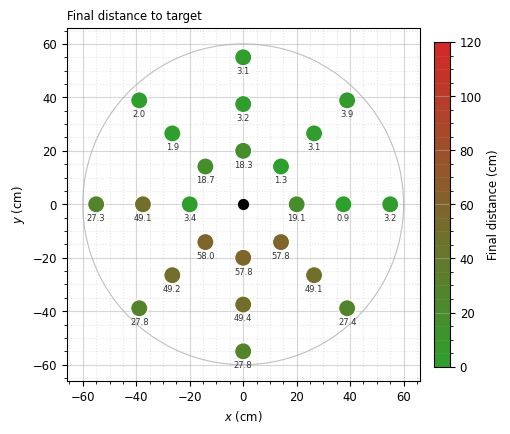

In [5]:
# ── 5. Display ────────────────────────────────────────────────────────────────
configure_screen()
fig = make_heatmap_figure(
    optimal_results,
    all_targets,
    arm_link=ARM_LINK,
    figsize=(5.0, 5.0),
)
apply_figure_style(fig)
plt.show()

In [6]:
# ── 6. PGF export ─────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC = 0.50
FIG_HEIGHT_FRAC = 0.32

configure_pgf()
fig = make_heatmap_figure(
    optimal_results,
    all_targets,
    arm_link=ARM_LINK,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "cartesian_control_constrained_heatmap.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/cartesian_control_constrained_heatmap.pgf


In [7]:
# ── 7. Caption ────────────────────────────────────────────────────────────────
caption = (
    r"As \autoref{fig:cartesian_control_heatmap}, but for the controller "
    r"re-optimised with the elbow anatomically constrained "
    r"($\theta_\mathrm{el} \in [0, \pi]$) via an independent TPE search "
    f"({CC_N_BO_TRIALS_CONSTRAINED} trials)."
)

save_caption(
    CAPTIONS_PATH / "cartesian_control_constrained_heatmap.tex",
    caption,
    NOTEBOOK_GITHUB_URL,
)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/cartesian_control_constrained_heatmap.tex
As \autoref{fig:cartesian_control_heatmap}, but for the controller re-optimised with the elbow anatomically constrained ($\theta_\mathrm{el} \in [0, \pi]$) via an independent TPE search (150 trials).
